In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from collections import Counter
from tqdm import trange

np.random.seed(0)

In [2]:
PERCENTAGE_TEST = 0.2

In [3]:
headernames = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"] 
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data", names=headernames)
df

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
y_col = "class"
x_cols = [c for c in headernames if c != y_col]
X, Y = np.asarray(df[x_cols]), np.asarray(df[y_col])

In [5]:
# normalization using min max scaling
max_v = X.max(axis=0)
min_v = X.min(axis=0)
X = (X - min_v) / (max_v - min_v)

In [6]:
# splitting the dataset
N = len(X)
perm = np.random.permutation(N)
x, y = X[perm], Y[perm]

n_test = int(N * PERCENTAGE_TEST)
x_train, y_train = x[n_test:], y[n_test:]
x_test, y_test = x[:n_test], y[:n_test]

In [7]:
def get_distances(x, p, axis=1):
  return np.linalg.norm(x - p, axis=axis)

def knn(x, y, p, k, is_classification=True):
  ''' Predict class of point p, based on the class 'y' of the k closest points '''
  dists = get_distances(x, p)
  nn_idx = np.argpartition(dists, k)[:k]
  if is_classification:
    return pd.value_counts(y[nn_idx]).idxmax()
  else:
    return y[nn_idx].mean()

100%|██████████| 6/6 [00:00<00:00, 269.18it/s]


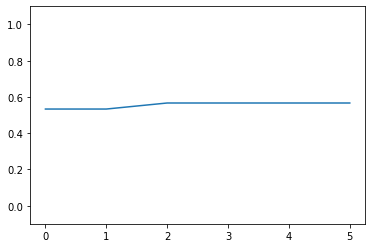

In [8]:
accuracies = []
for k in (t := trange(1, 12, 2)):
  preds = np.apply_along_axis(lambda p: knn(x_train, y_train, p, k), 1, x_test)
  acc = (y_test == preds).mean()
  accuracies.append(acc)

plt.ylim(-0.1, 1.1)
plt.plot(accuracies)

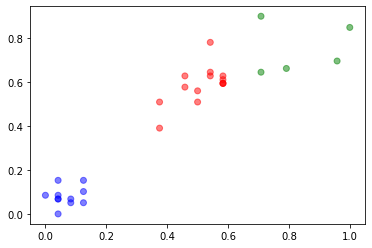

In [9]:
def color_conversion(l):
  # print(l)
  match l:
    case 0 | "Iris-versicolo": return "red"
    case 1 | "Iris-setosa": return "blue"
    case 2 | "Iris-virginica": return "green"
    case _: return "black"

preds = np.apply_along_axis(lambda p: knn(x_train, y_train, p, 3), 1, x_test)
colors = [color_conversion(l) for l in preds]
plt.scatter(x_test[:, headernames.index("petal_width")], x_test[:, headernames.index("petal_length")], c=colors, alpha=0.5)

In [10]:
def update_centroids(x, clusters, k):
  return np.array([x[clusters == i].mean(axis=0) for i in range(k)])

def get_clusters(x, centroids):
  dists = get_distances(x, centroids[:, np.newaxis, :], axis=2)
  return np.argmin(dists, axis=0)

def kmeans(x, k, max_iter=100):
  ''' Partition each observation into k clusters '''
  centroids = np.asarray(x[np.random.choice(len(x), k, replace=False)])
  for _ in range(max_iter):
    clusters = get_clusters(x, centroids)
    old_centroids = centroids
    centroids = update_centroids(x, clusters, k)
    if np.array_equal(centroids, old_centroids):
      break
  return clusters

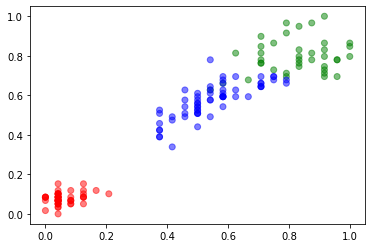

In [11]:
preds = kmeans(X, 3)
colors = [color_conversion(l) for l in preds]
plt.scatter(X[:, headernames.index("petal_width")], X[:, headernames.index("petal_length")], c=colors, alpha=0.5)

In [12]:
# testing kmeans accuracy
transformation = {}
for i in range(3):
  y, _ = Counter(Y[np.where(preds == i)]).most_common(1)[0]
  transformation[y] = i
accuracy = (preds == np.vectorize(transformation.get)(Y)).mean()
print(f"accuracy: {accuracy*100:.2f}%")

accuracy: 88.67%
